## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [1]:
# basic imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

### Details of input file (DESI DR1 Spectra)

In [2]:
# exploring ..data/desi/qso_test_spectra.fits file
hdul = fits.open(f'../data/desi/qso_test_spectra.fits')
header = hdul[0].header
hdul.close()
print(header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  AUTHOR  = 'A.Anand '                                                            FIT     = 'NMF     '                                                            SMOOTH  = 'MEDFILT: PIXSIZE=71'                                                 TGTQSO  = 'DESI DR1'                                                            END                                                                                                                                                                                                                                                                                                                                                                     

### Example output catalogs

I have already run `qsoabsfind` on `../data/desi/qso_test_spectra.fits` and saved the resulting catalogs to:

- `../data/desi/MgII_cat.fits`
- `../data/desi/CIV_cat.fits`

The configuration used for this run is provided in `data/example_config.yaml`. All other constants are default values.

### Exploring output

Reading extension 'PRIMARY' (PrimaryHDU)
Reading extension 'ABSORBER' (BinTableHDU)
Reading extension 'METADATA' (BinTableHDU)
Reading extension 'QSO_INFO' (BinTableHDU)
Reading extension 'COLUMN_DENSITY' (BinTableHDU)
Loaded 5 extensions from ../data/desi/MgII_cat.fits
  ABSORBER: 36 rows
  METADATA: 36 rows
  COLUMN_DENSITY: 36 rows
  QSO_INFO: 100 rows
INFO: Time taken to read catalog from ../data/desi/MgII_cat.fits 0.04 seconds


Text(0.5, 0, 'MgII redshift')

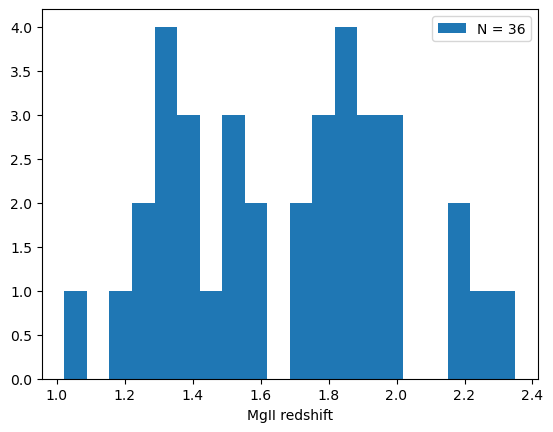

In [3]:
from qsoabsfind.datamodel import AbsorberData
mgii_tab = AbsorberData(f'../data/desi/MgII_cat.fits', autoload=True)
zabs = mgii_tab.catalog["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

Text(0.5, 0, '$EW_{\\rm MgII}\\, [\\AA]$')

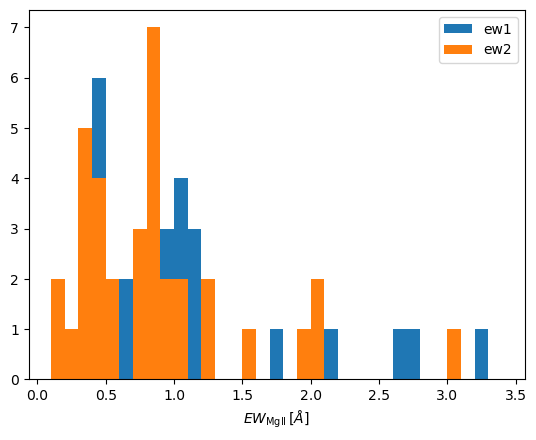

In [4]:
ew1 = mgii_tab.catalog["MGII_2796_EW"].data
ew2 = mgii_tab.catalog["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra

INFO: plotting QSO INDEX = 4...
INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.02 seconds


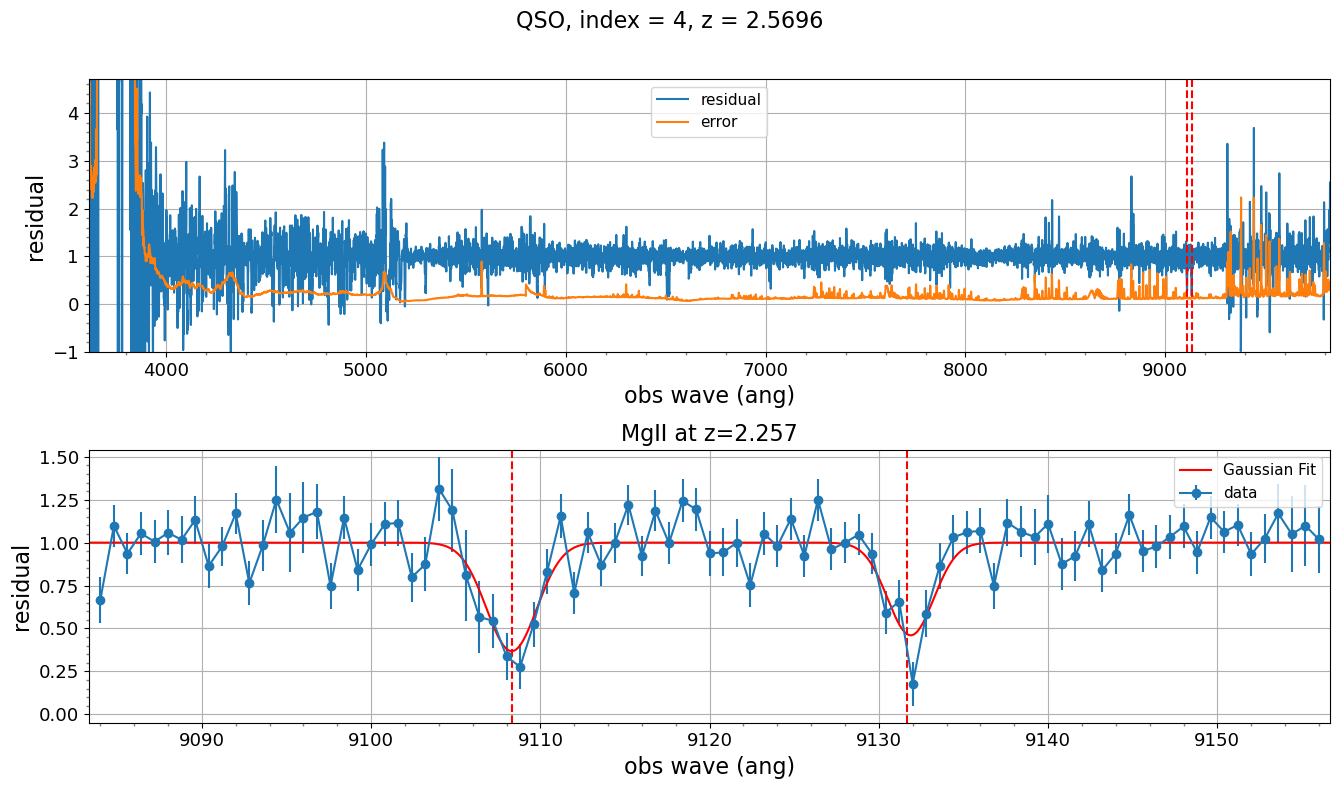

In [25]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead
import numpy as np

# select a random spectra from MgII_cat.fits
index = np.random.choice(mgii_tab.catalog["INDEX_SPEC"].data)
print(f'INFO: plotting QSO INDEX = {index}...')
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab.catalog[mgii_tab.catalog["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

2796.351037701003 2803.5886891580535 0.4571065821423849 0.4163628691704161


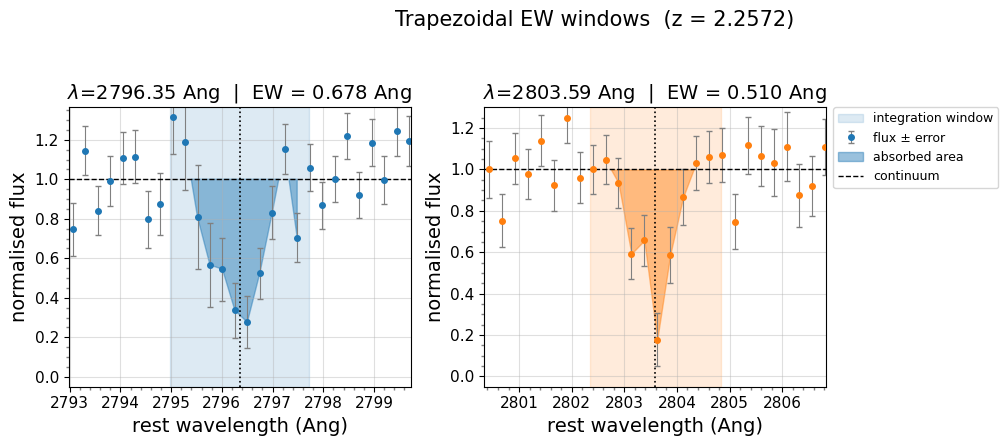

In [26]:
from qsoabsfind.utils import plot_trapezoidal_ew_windows

z = zabs["Z_ABS"][0]
gauss_fit = zabs["GAUSS_FIT"][0]
line1, line2 = gauss_fit[1], gauss_fit[4]
sigma1, sigma2 = gauss_fit[2], gauss_fit[5]

print(line1, line2, sigma1, sigma2)


plot_trapezoidal_ew_windows(
    spectra.wavelength, spectra.flux, spectra.error, z=z,
    line1=line1, line2=line2,
    sigma1=sigma1, sigma2=sigma2,
    n_sigma=3,
)

### Using qsoabsfind internally as module

In [7]:
# if want to run qsoabsfind on one spectrum
from qsoabsfind.absfinder import read_single_spectrum_and_find_absorber
from qsoabsfind.config import load_constants
help(read_single_spectrum_and_find_absorber)

Help on function read_single_spectrum_and_find_absorber in module qsoabsfind.absfinder:

read_single_spectrum_and_find_absorber(fits_file, spec_index, absorber, **kwargs)
    This function retrieves a single QSO spectrum from a FITS file, processes the data to remove NaNs,
    and prepares the spectrum for absorber search within specified wavelength regions
    and runs the convolution based adaptive S/N method to detect absorbers in the spectrum.
    
    Args:
        fits_file (str): Path to the FITS file containing normalized QSO spectra.
                         The file must include extensions for FLUX, ERROR, WAVELENGTH
                         and METADATA which must contain keyword Z_QSO.
        spec_index (int): Index of the quasar spectrum to retrieve from the FITS file.
        absorber (str): Name of the absorber to search for (e.g., MgII, CIV, OVI, NV, SiIV, AlIII, FeII, CaII, NaI).
        kwargs (dict): search parameters as taken in convolution_method..()
            A

In [8]:
parameters = load_constants(f'../data/desi/desi_constants.py')
read_single_spectrum_and_find_absorber(f'../data/desi/qso_test_spectra.fits', index, 'MgII', **parameters.search_parameters)

/Users/abhijeet/software/myprojects/qsoabsfind/qsoabsfind/ew.py:77: RuntimeWarning: invalid value encountered in sqrt
  save_param_error = np.sqrt(np.diag(pcov))
/Users/abhijeet/opt/anaconda3/envs/my_software/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


{'index_spec': [54, 54],
 'z_abs': [1.3653806511985747, 1.391341197244226],
 'gauss_fit': [[0.9284033086958636,
   2796.3499971496767,
   0.44534240681812004,
   0.7139711339325706,
   2803.5913758046704,
   0.5181218540237398],
  [0.6710866087712598,
   2796.3499992750217,
   0.33495037183139464,
   0.4639822097204579,
   2803.4324733965077,
   0.4210822867204892]],
 'gauss_fit_std': [[0.048471474025412215,
   0.03011658643474214,
   0.03091687151071424,
   0.047266927006188786,
   0.04397618047588885,
   0.045432103763278685],
  [0.059420954056651105,
   0.03563384006446355,
   0.03651955761901148,
   0.05652285877198426,
   0.06124088792706578,
   0.061925629707929274]],
 'ew_1_mean': [1.036383867263794, 0.5634416937828064],
 'ew_2_mean': [0.9272620677947998, 0.48973172903060913],
 'ew_total_mean': [1.9636460542678833, 1.0531734228134155],
 'ew_1_error': [0.017839480191469193, 0.011542310006916523],
 'ew_2_error': [0.019920632243156433, 0.01236172765493393],
 'ew_total_error': [0.02

Reading extension 'PRIMARY' (PrimaryHDU)
Reading extension 'ABSORBER' (BinTableHDU)
Reading extension 'METADATA' (BinTableHDU)
Reading extension 'QSO_INFO' (BinTableHDU)
Reading extension 'COLUMN_DENSITY' (BinTableHDU)
Loaded 5 extensions from ../data/desi/CIV_cat.fits
  ABSORBER: 8 rows
  METADATA: 8 rows
  COLUMN_DENSITY: 8 rows
  QSO_INFO: 100 rows
INFO: Time taken to read catalog from ../data/desi/CIV_cat.fits 0.04 seconds


Text(0.5, 0, 'CIV redshift')

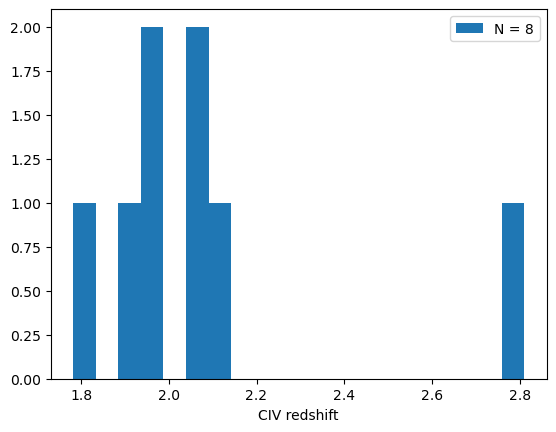

In [9]:
civ_tab = AbsorberData(f'../data/desi/CIV_cat.fits', autoload=True)
civ_zabs = civ_tab.catalog["Z_ABS"].data
plt.hist(civ_zabs, bins=20, label = f'N = {civ_zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')

INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.02 seconds
INFO: plotting CIV for QSO INDEX = 19...


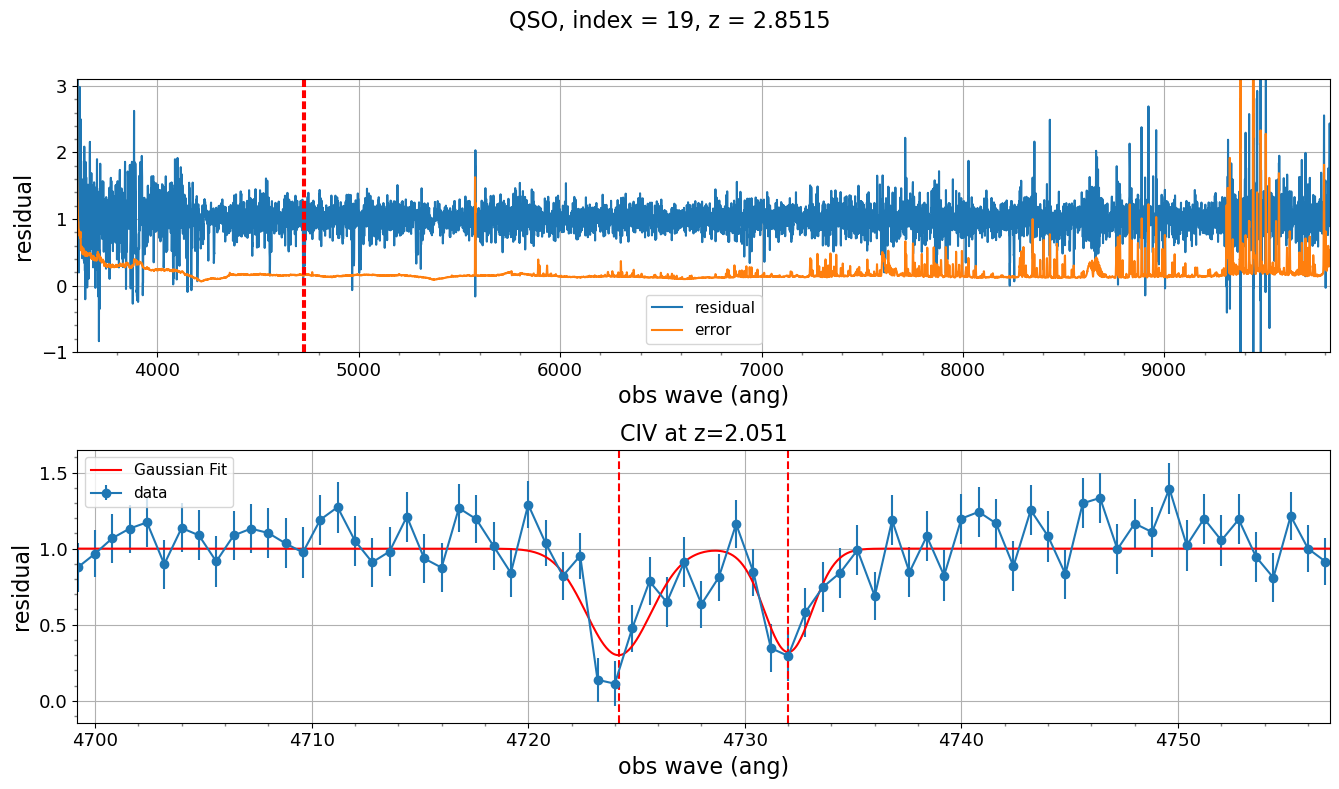

In [10]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead

# select a random spectra from MgII_cat.fits
index1 = np.random.choice(civ_tab.catalog["INDEX_SPEC"].data)
spectra1 = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index1, autoload=True)
print(f'INFO: plotting CIV for QSO INDEX = {index1}...')
# select corresponding zabs table
zabs1 = civ_tab.catalog[civ_tab.catalog["INDEX_SPEC"].data==index1]
plot_absorber(spectra1, 'CIV', zabs1, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index1}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

1548.1995896349197 1550.7666626200769 0.48801170912536584 0.35705974523737605


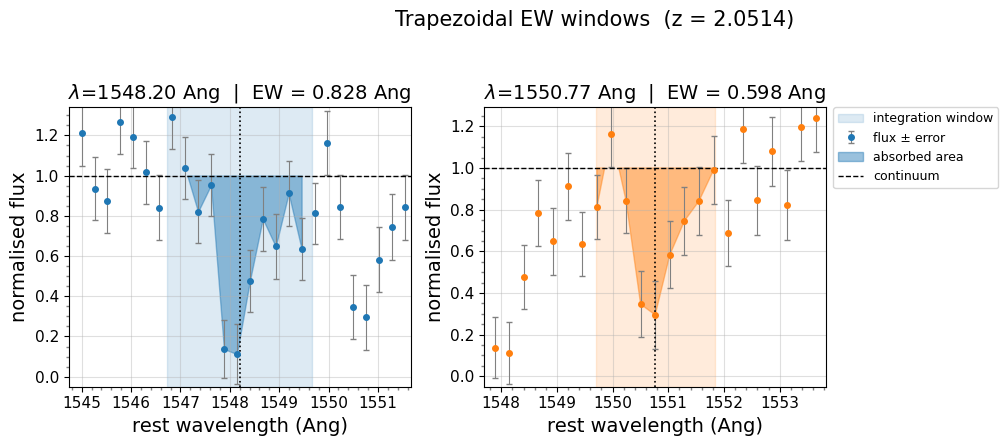

In [11]:
from qsoabsfind.utils import plot_trapezoidal_ew_windows

z1 = zabs1["Z_ABS"][0]
gauss_fit1 = zabs1["GAUSS_FIT"][0]
line1_1, line2_1 = gauss_fit1[1], gauss_fit1[4]
sigma1_1, sigma2_1 = gauss_fit1[2], gauss_fit1[5]

print(line1_1, line2_1, sigma1_1, sigma2_1)


plot_trapezoidal_ew_windows(
    spectra1.wavelength, spectra1.flux, spectra1.error, z=z1,
    line1=line1_1, line2=line2_1,
    sigma1=sigma1_1, sigma2=sigma2_1,
    n_sigma=3,
)